# CNN 2D Dataset Preparation

This notebook combines the existing Waymo training and validation manifests, keeps the three selected maneuver classes, examines the full filtered dataset, creates new stratified 70/15/15 splits, and saves path-based CSV files.

No CNN model is built and no image arrays are flattened in this notebook.

## 1. Imports and paths

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
CLASS_ORDER = ['straight', 'right-turn', 'left-turn']
CLASS_COLORS = {
    'straight': 'steelblue',
    'right-turn': 'darkorange',
    'left-turn': 'seagreen',
}

In [2]:
# Use the project root whether the notebook starts from the project root
# or from inside the notebooks directory.
current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == 'notebooks' else current_dir

DATA_DIR = PROJECT_ROOT / 'data'
PROCESSED_DATA_DIR = DATA_DIR / 'processed' / 'waymo_e2e'

TRAIN_MANIFEST_PATH = DATA_DIR / 'train_manifest.json'
VAL_MANIFEST_PATH = DATA_DIR / 'val_manifest.json'

TRAIN_NPZ_DIR = PROCESSED_DATA_DIR / 'training'
VAL_NPZ_DIR = PROCESSED_DATA_DIR / 'val'

# Use test only if the validation frames were stored there instead of val.
if not VAL_NPZ_DIR.exists():
    VAL_NPZ_DIR = PROCESSED_DATA_DIR / 'test'

OUTPUT_DIR = PROCESSED_DATA_DIR / 'CNN_2D'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required_paths = [
    TRAIN_MANIFEST_PATH,
    VAL_MANIFEST_PATH,
    TRAIN_NPZ_DIR,
    VAL_NPZ_DIR,
]

for required_path in required_paths:
    if not required_path.exists():
        raise FileNotFoundError(f'Required path not found: {required_path}')

print(f'Project root: {PROJECT_ROOT}')
print(f'Training frames: {TRAIN_NPZ_DIR}')
print(f'Validation frames: {VAL_NPZ_DIR}')
print(f'CSV output directory: {OUTPUT_DIR}')

Project root: C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final
Training frames: C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\training
Validation frames: C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\val
CSV output directory: C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\CNN_2D


## 2. Load and combine the training and validation manifests

In [3]:
def manifest_to_df(manifest_path, frame_dir):
    # Load the sequence-level manifest.
    with open(manifest_path, 'r', encoding='utf-8') as f:
        manifest = json.load(f)

    # Store project-relative paths so the CSV files remain portable.
    relative_frame_dir = frame_dir.relative_to(PROJECT_ROOT)
    rows = []

    for sequence_data in manifest.values():
        frame_path = relative_frame_dir / sequence_data['target_fname']
        rows.append({
            'target_frame_path': frame_path.as_posix(),
            'class_label': sequence_data['label'],
        })

    return pd.DataFrame(rows)


df_original_train = manifest_to_df(TRAIN_MANIFEST_PATH, TRAIN_NPZ_DIR)
df_original_val = manifest_to_df(VAL_MANIFEST_PATH, VAL_NPZ_DIR)

# Combine the original training and validation data before making new splits.
df_combined = pd.concat(
    [df_original_train, df_original_val],
    ignore_index=True,
)

print(f'Original training rows: {len(df_original_train):,}')
print(f'Original validation rows: {len(df_original_val):,}')
print(f'Combined rows: {len(df_combined):,}')

df_combined.head()

Original training rows: 2,037
Original validation rows: 479
Combined rows: 2,516


,target_frame_path,class_label
0,data/processed/waymo_e2e/training/003b62820d0e...,straight
1,data/processed/waymo_e2e/training/0042b483892d...,left-turn
2,data/processed/waymo_e2e/training/007083e22896...,left-turn
3,data/processed/waymo_e2e/training/00a858a5e348...,straight
4,data/processed/waymo_e2e/training/00f20fd34a1f...,straight


## 3. Keep only straight, right-turn, and left-turn

In [4]:
# Remove stationary and lane-change examples.
df_full = df_combined[
    df_combined['class_label'].isin(CLASS_ORDER)
].copy().reset_index(drop=True)

removed_rows = len(df_combined) - len(df_full)
missing_classes = [
    class_name
    for class_name in CLASS_ORDER
    if class_name not in df_full['class_label'].unique()
]

if missing_classes:
    raise ValueError(f'Missing requested classes: {missing_classes}')

print(f'Rows retained: {len(df_full):,}')
print(f'Rows removed: {removed_rows:,}')

df_full.head()

Rows retained: 1,966
Rows removed: 550


,target_frame_path,class_label
0,data/processed/waymo_e2e/training/003b62820d0e...,straight
1,data/processed/waymo_e2e/training/0042b483892d...,left-turn
2,data/processed/waymo_e2e/training/007083e22896...,left-turn
3,data/processed/waymo_e2e/training/00a858a5e348...,straight
4,data/processed/waymo_e2e/training/00f20fd34a1f...,straight


## 4. Examine the full filtered dataset before splitting

In [5]:
full_counts = (
    df_full['class_label']
    .value_counts()
    .reindex(CLASS_ORDER, fill_value=0)
)
full_percentages = full_counts / len(df_full) * 100

print(f'Full filtered dataset: {len(df_full):,} images')
for class_name in CLASS_ORDER:
    print(
        f'  {class_name}: {full_counts[class_name]:,} '
        f'({full_percentages[class_name]:.2f}%)'
    )

Full filtered dataset: 1,966 images
  straight: 906 (46.08%)
  right-turn: 589 (29.96%)
  left-turn: 471 (23.96%)


In [6]:
def load_image(fpath):
    data = np.load(fpath, allow_pickle=True)
    modality = data['_modality_data'].item()
    keys = list(modality.keys())
    img = modality[keys[0]]  # CAMERAS is always first key

    if img.dtype in [np.float32, np.float64]:
        img = np.clip(img, 0, 1)
    else:
        img = img.astype(np.uint8)

    return img

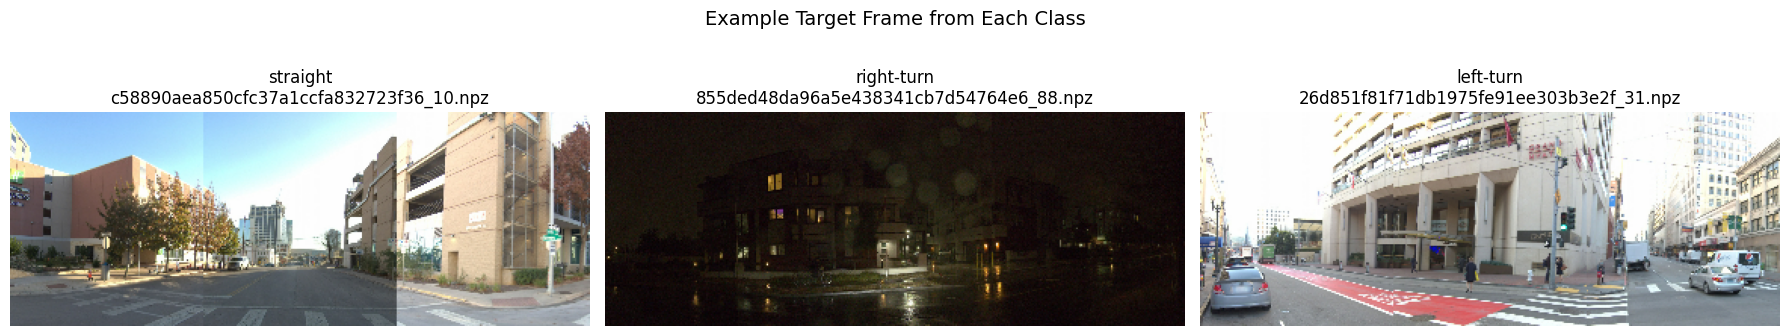

In [7]:
# Show one reproducible example from each retained class.
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, class_name in zip(axes, CLASS_ORDER):
    sample_row = (
        df_full[df_full['class_label'] == class_name]
        .sample(n=1, random_state=RANDOM_STATE)
        .iloc[0]
    )

    relative_path = Path(sample_row['target_frame_path'])
    image_path = PROJECT_ROOT / relative_path
    img = load_image(image_path)

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'{class_name}\n{relative_path.name}')

plt.suptitle('Example Target Frame from Each Class', fontsize=14)
plt.tight_layout()
plt.show()

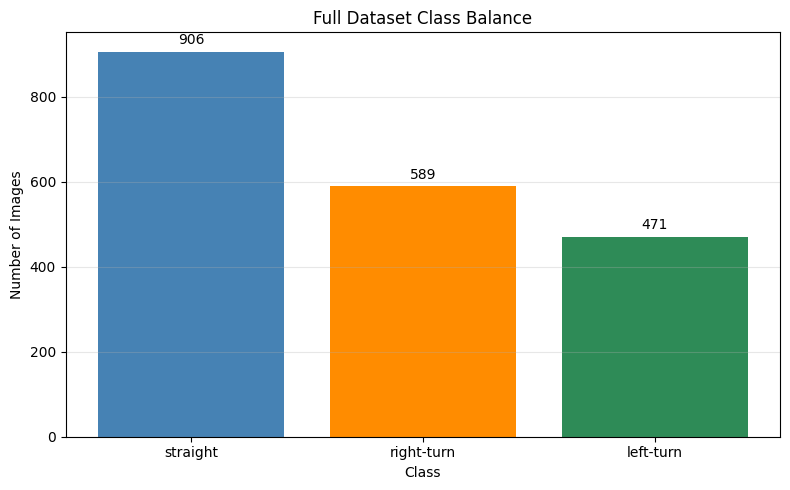

In [8]:
# Plot the full-dataset class balance.
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    CLASS_ORDER,
    full_counts.values,
    color=[CLASS_COLORS[class_name] for class_name in CLASS_ORDER],
)

ax.bar_label(bars, labels=[f'{count:,}' for count in full_counts.values], padding=3)
ax.set_title('Full Dataset Class Balance')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Create stratified 70/15/15 train, validation, and test splits

In [9]:
# First keep 70% for training and hold out 30% for validation and testing.
df_train, df_remaining = train_test_split(
    df_full,
    test_size=0.30,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=df_full['class_label'],
)

# Divide the remaining 30% equally into 15% validation and 15% testing.
df_val, df_test = train_test_split(
    df_remaining,
    test_size=0.50,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=df_remaining['class_label'],
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

splits = {
    'train': df_train,
    'val': df_val,
    'test': df_test,
}

assert sum(len(split_df) for split_df in splits.values()) == len(df_full)

for split_name, split_df in splits.items():
    split_counts = (
        split_df['class_label']
        .value_counts()
        .reindex(CLASS_ORDER, fill_value=0)
    )
    split_percentages = split_counts / len(split_df) * 100

    print(
        f'\n{split_name.upper()} split: {len(split_df):,} images '
        f'({len(split_df) / len(df_full) * 100:.2f}% of full dataset)'
    )

    for class_name in CLASS_ORDER:
        print(
            f'  {class_name}: {split_counts[class_name]:,} '
            f'({split_percentages[class_name]:.2f}%)'
        )


TRAIN split: 1,376 images (69.99% of full dataset)
  straight: 634 (46.08%)
  right-turn: 412 (29.94%)
  left-turn: 330 (23.98%)

VAL split: 295 images (15.01% of full dataset)
  straight: 136 (46.10%)
  right-turn: 89 (30.17%)
  left-turn: 70 (23.73%)

TEST split: 295 images (15.01% of full dataset)
  straight: 136 (46.10%)
  right-turn: 88 (29.83%)
  left-turn: 71 (24.07%)


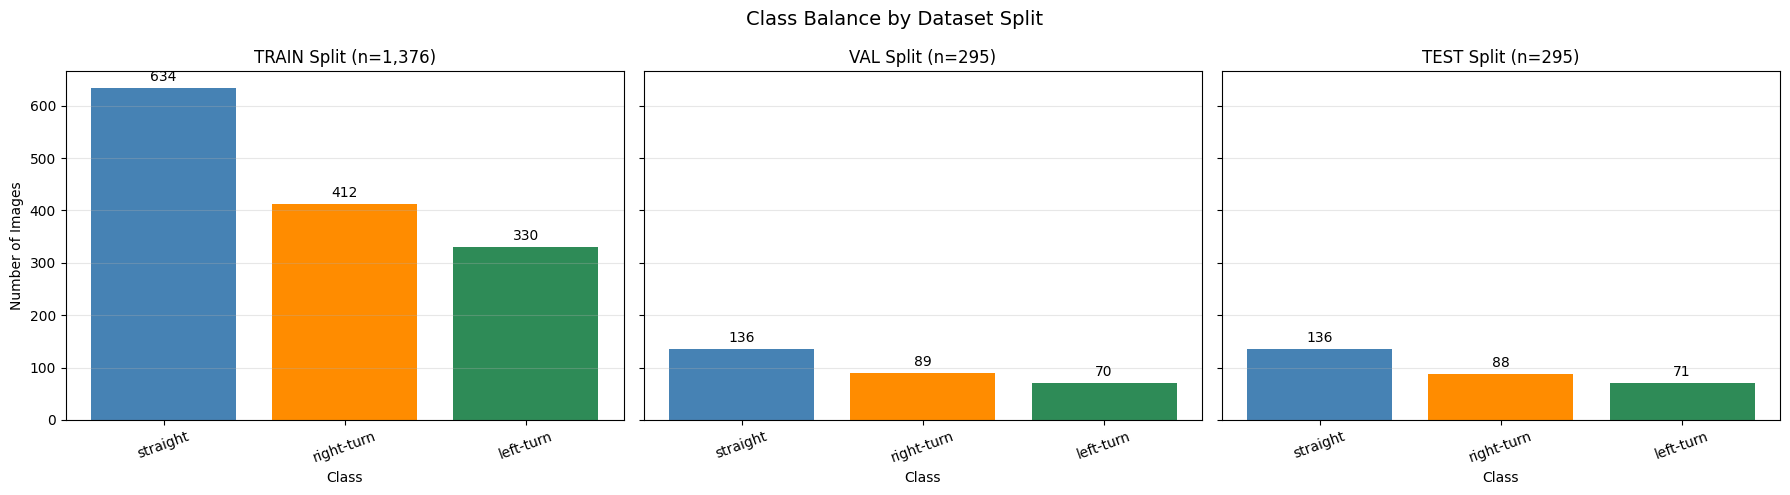

In [10]:
# Compare class balance across the three new splits.
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (split_name, split_df) in zip(axes, splits.items()):
    split_counts = (
        split_df['class_label']
        .value_counts()
        .reindex(CLASS_ORDER, fill_value=0)
    )

    bars = ax.bar(
        CLASS_ORDER,
        split_counts.values,
        color=[CLASS_COLORS[class_name] for class_name in CLASS_ORDER],
    )

    ax.bar_label(
        bars,
        labels=[f'{count:,}' for count in split_counts.values],
        padding=3,
    )
    ax.set_title(f'{split_name.upper()} Split (n={len(split_df):,})')
    ax.set_xlabel('Class')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Number of Images')
plt.suptitle('Class Balance by Dataset Split', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Save the split dataframes and label files

Each `df_*.csv` file contains the project-relative target-frame path and its class label. Each `y_*.csv` file contains only the class-label column. The image arrays will be created separately later.

In [11]:
saved_files = []

for split_name, split_df in splits.items():
    df_output_path = OUTPUT_DIR / f'df_{split_name}.csv'
    y_output_path = OUTPUT_DIR / f'y_{split_name}.csv'

    # Save the frame path and class label together.
    split_df.to_csv(df_output_path, index=False)

    # Save a separate single-column target file for later model training.
    split_df[['class_label']].to_csv(y_output_path, index=False)

    saved_files.extend([df_output_path, y_output_path])

print('Saved files:')
for saved_path in saved_files:
    print(f'  {saved_path}')

Saved files:
  C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\CNN_2D\df_train.csv
  C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\CNN_2D\y_train.csv
  C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\CNN_2D\df_val.csv
  C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\CNN_2D\y_val.csv
  C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\CNN_2D\df_test.csv
  C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\CNN_2D\y_test.csv
